# Lab Assignment 4: Support Vector Machines

In this exercise, we return to the wine quality dataset. However, this time, we will attempt to separate various pieces of cloathing using a Support Vector Machine (SVM). Below, we gather the data and preprocess it for you. As your task, you need to implement an SVM solver, perform finetuning and classification, and finally, show your results using a confusion matrix.

## Library installation
In this lab we will use the `cvxopt` package, [whose documentation can be found here](https://cvxopt.org/userguide/index.html).

We are running version 1.3.2 of `cvxopt`.

In [11]:
pip install scikit-learn



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Package Imports

In [12]:
## =======================================================
## Import Key Packages
## =======================================================
## Standard Fare
import numpy as np
from scipy.io import loadmat

## CVX Opt
import cvxopt
from cvxopt import solvers
from cvxopt import matrix
from sklearn.model_selection import train_test_split
import pandas as pd

solvers.options['show_progress'] = False

## Accessing the Data

In [13]:
training_data = pd.read_csv('./fashion-mnist_train.csv')

y = training_data['label']
X = training_data.drop('label',axis=1)

X = X[:2000]
y = y[:2000]

train_samples, test_samples, train_samples_labels, test_samples_labels = train_test_split(X, y, test_size=0.1, random_state=42, shuffle=True)

test_samples_labels=np.squeeze(test_samples_labels)
train_samples_labels=np.squeeze(train_samples_labels)

In [14]:
label_to_title = {0: 'T-shirt/top', 
                  1:'Trouser', 
                  2:'Pullover', 
                  3:'Dress', 
                  4:'Coat', 
                  5:'Sandal',
                  6:'Shirt', 
                  7:'Sneaker', 
                  8:'Bag',
                  9:'Ankle boot'}

In [15]:
print(np.unique(train_samples_labels))
print(np.unique(test_samples_labels))

for i in np.unique(train_samples_labels):
    print(f' There are {sum(train_samples_labels==i)} instances of label #{i}:{label_to_title[i]} in the Train dataset')

[0 1 2 3 4 5 6 7 8 9]
[0 1 2 3 4 5 6 7 8 9]
 There are 197 instances of label #0:T-shirt/top in the Train dataset
 There are 182 instances of label #1:Trouser in the Train dataset
 There are 187 instances of label #2:Pullover in the Train dataset
 There are 190 instances of label #3:Dress in the Train dataset
 There are 200 instances of label #4:Coat in the Train dataset
 There are 160 instances of label #5:Sandal in the Train dataset
 There are 188 instances of label #6:Shirt in the Train dataset
 There are 165 instances of label #7:Sneaker in the Train dataset
 There are 168 instances of label #8:Bag in the Train dataset
 There are 163 instances of label #9:Ankle boot in the Train dataset


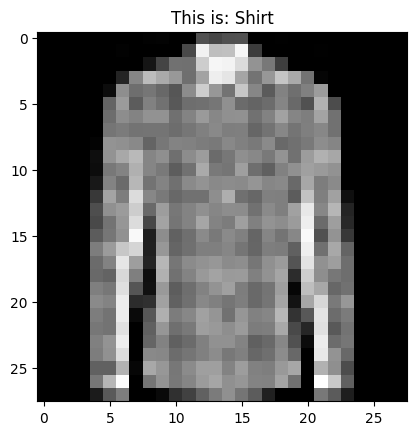

In [16]:
import matplotlib.pyplot as plt
import random

ind = random.randint(0,2000)
plt.imshow(X[ind:ind+1].values.reshape(28,28),cmap='gray')
plt.title(f'This is: {label_to_title[y[ind:ind+1].values[0]]}')
plt.show()

## Task 1:
Develop code for training an SVM for binary classification with nonlinear kernels. You'll need to accomodate non-overlapping class distributions. One way to implement this is to maximize (7.32) subject to (7.33) and (7.34) [in Bishop](https://www.microsoft.com/en-us/research/uploads/prod/2006/01/Bishop-Pattern-Recognition-and-Machine-Learning-2006.pdf). It may be helpful to redefine these as matrix operations. Let ${1}\in\mathbb{R}^{N\times 1}$ be the vector whose entries are all 1's. Let $\mathbf{a}\in\mathbb{R}^{N\times 1}$ have entries $a_i$. Let $\mathbf{T}\in\mathbb{R}^{N\times N}$ be a diagonal matrix with $\mathbf{T}_{ii} = t_i$ on the diagonal. Then we can reformulate the objective to be

\begin{equation*}
\begin{aligned}
& \text{maximize}
& & \tilde{L}(\mathbf{a}) = {1}^{\mathrm{T}}\mathbf{a} - \frac{1}{2} \mathbf{a}^{\mathrm{T}} \mathbf{T}\mathbf{K} \mathbf{T}\mathbf{a} \\
& \text{subject to}
& & {1}^{\mathrm{T}} \mathbf{a} \preceq C \\
& & & {1}^{\mathrm{T}} \mathbf{a} \succeq 0 \\
& & & \mathbf{a}^{\mathrm{T}} \mathbf{t} = 0
\end{aligned}
\end{equation*}

The "$\preceq$" symbol here means element-wise comparison. This formulation is very close to what `cvxopt` expects.

Hint (`cvxopt` expects the following form):

\begin{equation*}
\begin{aligned}
& \text{minimize}
& & \tilde{L}(\mathbf{a}) = \frac{1}{2} \mathbf{a}^{\mathrm{T}} \mathbf{T}\mathbf{K} \mathbf{T}\mathbf{a} - {1}^{\mathrm{T}}\mathbf{a} \\
& \text{subject to}
& & G \mathbf{a} \preceq h \\
& & & {\mathbf{t}}^{\mathrm{T}}\mathbf{a} = 0
\end{aligned}
\end{equation*}

where $G$ is an $N\times N$ identity matrix ontop of $-1$ times an $N\times N$ identity matrix and $h \in\mathbb{R}^{2N}$ where the first $N$ entries are $C$ and the second $N$ enties are $0$.

## Task 2:
Develop code to predict the $\{-1,+1\}$ class for new data. To use the predictive model (7.13) you need to determine $b$, which can be done with (7.37). 

We have provided some starter code in the cells below

In [17]:
def nonlinear_kernel(X, y, kernel="rbf", gamma=None, degree=3, coef0=1.0):
  """
  Implement a nonlinear kernel function. Function parameters will vary depending on kernel function.
  Feel free to implement either 'rbf', 'poly' or 'sigmoid'
  WARNING: 'rbf' can be quite slow and there exist some approximation methods
  Parameters
  ----------
  X : {array-like, sparse matrix} of shape (n_samples, n_features) or (n_samples, n_samples)
    Training vectors, where n_samples is the number of samples and n_features 
    is the number of features. For kernel=”precomputed”, the expected shape 
    of X is (n_samples, n_samples).

  y : array-like of shape (n_samples,)
    Target values (class labels in classification, real numbers in regression).
  """
  X = np.asarray(X, dtype=np.float64)
  y = np.asarray(y, dtype=np.float64)

  if X.ndim == 1:
    X = X.reshape(1, -1)
  if y.ndim == 1:
    y = y.reshape(1, -1)

  if X.shape[1] != y.shape[1]:
    raise ValueError("X and y must have the same number of features")

  if gamma is None:
    gamma = 1.0 / X.shape[1]

  if kernel == "rbf":
    X_sq = np.sum(X ** 2, axis=1)[:, None]
    y_sq = np.sum(y ** 2, axis=1)[None, :]
    sq_dists = np.maximum(X_sq + y_sq - 2.0 * (X @ y.T), 0.0)
    return np.exp(-gamma * sq_dists)
  if kernel == "poly":
    return (gamma * (X @ y.T) + coef0) ** degree
  if kernel == "sigmoid":
    return np.tanh(gamma * (X @ y.T) + coef0)

  raise ValueError("kernel must be one of {'rbf', 'poly', 'sigmoid'}")

In [18]:
class SVM(object):

  def __init__(self, kernel=nonlinear_kernel, C=1.0):
    """
    Initialize SVM

    Parameters
    ----------
    kernel : callable
      Specifies the kernel type to be used in the algorithm. It is used to pre-compute 
      the kernel matrix from data matrices; that matrix should be an array 
      of shape (n_samples, n_samples).
    C : float, default=1.0
      Regularization parameter. The strength of the regularization is inversely
      proportional to C. Must be strictly positive. The penalty is a squared l2
      penalty.
    """
    self.kernel = kernel
    self.C = C
    self.alphas = None
    self.support_vector_mask = None
    self.X_train = None
    self.y_train = None
    self.b = 0.0

  def fit(self, X, y):
    """
    Fit the SVM model according to the given training data.

    Parameters
    ----------
    X : {array-like, sparse matrix} of shape (n_samples, n_features) or (n_samples, n_samples)
      Training vectors, where n_samples is the number of samples and n_features 
      is the number of features. For kernel=”precomputed”, the expected shape 
      of X is (n_samples, n_samples).

    y : array-like of shape (n_samples,)
      Target values (class labels in classification, real numbers in regression).

    Returns
    -------
    self : object
      Fitted estimator.
    """
    # Hint:
    # 1. Define Quadratic Programming (QP) parameters. Given a QP optimization 
    #    problem in standard form, cvxopt is looking for P, q, G, h, A, and b
    #    (https://cvxopt.org/userguide/coneprog.html#quadratic-cone-programs).
    # 2. Construct the QP, invoke solver (use cvxopt.solvers.qp to maximize the Lagrange (7.32))
    # 3. Extract optimal value and solution. cvxopt.solvers.qp(P, q, G, h, A, b)["x"]
    #    are the Lagrange multipliers.
    X = np.asarray(X, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64).reshape(-1)

    if not np.array_equal(np.unique(y), np.array([-1.0, 1.0])):
      raise ValueError("SVM expects binary labels encoded as -1 and +1")

    n_samples = X.shape[0]
    K = self.kernel(X, X)
    K = 0.5 * (K + K.T)

    P = matrix(np.outer(y, y) * K, tc='d')
    q = matrix(-np.ones(n_samples), tc='d')

    G = matrix(np.vstack((np.eye(n_samples), -np.eye(n_samples))), tc='d')
    h = matrix(np.hstack((np.full(n_samples, self.C), np.zeros(n_samples))), tc='d')

    A = matrix(y.reshape(1, -1), tc='d')
    b = matrix(np.array([0.0]), tc='d')

    solution = solvers.qp(P, q, G, h, A, b)
    alphas = np.ravel(solution['x'])

    tol = 1e-6
    support_mask = alphas > tol
    if not np.any(support_mask):
      raise RuntimeError("No support vectors found. Try a different C or kernel setup.")

    self.alphas = alphas[support_mask]
    self.support_vector_mask = support_mask
    self.X_train = X[support_mask]
    self.y_train = y[support_mask]

    margin_mask = (alphas > tol) & (alphas < self.C - tol)
    if not np.any(margin_mask):
      margin_mask = support_mask

    weighted = alphas * y
    b_vals = y[margin_mask] - weighted @ K[:, margin_mask]
    self.b = np.mean(b_vals)

    return self

  def decision_function(self, X):
    X = np.asarray(X, dtype=np.float64)
    if X.ndim == 1:
      X = X.reshape(1, -1)
    K = self.kernel(self.X_train, X)
    return (self.alphas * self.y_train) @ K + self.b

  def predict(self, X):
    """
    Perform classification on samples in X.

    For an one-class model, +1 or -1 is returned.

    Parameters
    ----------
    X : {array-like, sparse matrix} of shape (n_samples, n_features) or (n_samples_test, n_samples_train)

    Returns
    -------
    y_pred : ndarray of shape (n_samples,)
      Class labels for samples in X.
    """
    scores = self.decision_function(X)
    return np.where(scores >= 0, 1, -1)

  def score(self, X, y):
    """
    Return the mean accuracy on the given test data and labels. 
    
    In multi-label classification, this is the subset accuracy which is a harsh 
    metric since you require for each sample that each label set be correctly 
    predicted.

    Parameters
    ----------
    X : array-like of shape (n_samples, n_features)
      Test samples.
    y : array-like of shape (n_samples,) or (n_samples, n_outputs)
      True labels for X.

    Return
    ------
    score : float
      Mean accuracy of self.predict(X)
    """
    y_true = np.asarray(y).reshape(-1)
    y_pred = self.predict(X)
    return np.mean(y_pred == y_true)

## Task 3:
Using your implementation, compare multiclass classification performance of two different voting schemes:
* one vs. rest
* one vs. one

In [19]:
from itertools import combinations

# Convert to numpy and scale intensities for numerical stability.
X_train_np = train_samples.to_numpy(dtype=np.float64) / 255.0
X_test_np = test_samples.to_numpy(dtype=np.float64) / 255.0
y_train_np = np.asarray(train_samples_labels, dtype=int)
y_test_np = np.asarray(test_samples_labels, dtype=int)
class_labels = np.unique(y_train_np)

# Nonlinear kernel used for all multiclass experiments.
kernel_fn = lambda A, B: nonlinear_kernel(
    A,
    B,
    kernel="poly",
    degree=2,
    gamma=1.0 / X_train_np.shape[1],
    coef0=1.0,
)

def train_one_vs_rest(X, y, labels, C, kernel):
  models = {}
  for label in labels:
    y_binary = np.where(y == label, 1, -1)
    models[label] = SVM(kernel=kernel, C=C).fit(X, y_binary)
  return models

def predict_one_vs_rest(models, labels, X):
  scores = []
  for label in labels:
    scores.append(models[label].decision_function(X))
  scores = np.vstack(scores).T
  return labels[np.argmax(scores, axis=1)]

def train_one_vs_one(X, y, labels, C, kernel):
  pair_models = {}
  for label_a, label_b in combinations(labels, 2):
    pair_mask = (y == label_a) | (y == label_b)
    X_pair = X[pair_mask]
    y_pair = np.where(y[pair_mask] == label_a, 1, -1)
    pair_models[(label_a, label_b)] = SVM(kernel=kernel, C=C).fit(X_pair, y_pair)
  return pair_models

def predict_one_vs_one(pair_models, labels, X):
  votes = np.zeros((X.shape[0], labels.size), dtype=np.int32)
  confidence = np.zeros((X.shape[0], labels.size), dtype=np.float64)
  label_to_idx = {label: idx for idx, label in enumerate(labels)}

  for (label_a, label_b), model in pair_models.items():
    scores = model.decision_function(X)
    pred = np.where(scores >= 0, label_a, label_b)

    idx_a = label_to_idx[label_a]
    idx_b = label_to_idx[label_b]

    votes[:, idx_a] += (pred == label_a).astype(np.int32)
    votes[:, idx_b] += (pred == label_b).astype(np.int32)

    # Tie-break support: signed confidence accumulation.
    confidence[:, idx_a] += scores
    confidence[:, idx_b] -= scores

  winners = np.argmax(votes, axis=1)
  max_votes = votes.max(axis=1, keepdims=True)
  ties = votes == max_votes

  for i in range(X.shape[0]):
    tied_idx = np.where(ties[i])[0]
    if tied_idx.size > 1:
      winners[i] = tied_idx[np.argmax(confidence[i, tied_idx])]

  return labels[winners]

In [20]:
# Task 3: compare One-vs-Rest and One-vs-One performance.
C_value = 50.0

ovr_models = train_one_vs_rest(X_train_np, y_train_np, class_labels, C=C_value, kernel=kernel_fn)
ovr_predictions = predict_one_vs_rest(ovr_models, class_labels, X_test_np)
ovr_accuracy = np.mean(ovr_predictions == y_test_np)

ovo_models = train_one_vs_one(X_train_np, y_train_np, class_labels, C=C_value, kernel=kernel_fn)
ovo_predictions = predict_one_vs_one(ovo_models, class_labels, X_test_np)
ovo_accuracy = np.mean(ovo_predictions == y_test_np)

print(f"Task 3 - One-vs-Rest accuracy (C={C_value}): {ovr_accuracy:.4f}")
print(f"Task 3 - One-vs-One  accuracy (C={C_value}): {ovo_accuracy:.4f}")

Task 3 - One-vs-Rest accuracy (C=50.0): 0.8650
Task 3 - One-vs-One  accuracy (C=50.0): 0.8600


## Task 4:
The parameter $C>0$ controls the tradeoff between the size of the margin and the slack variable penalty. It is analogous to the inverse of a regularization coefficient. Include in your report a brief discussion of how you found an appropriate value.

Hint: Try using np.linspace or logspace for hyperparameter tuning

Hint: I recommend **high** C 

In [21]:
# Task 4: tune C using a validation split (high-C range per prompt recommendation).
X_tune_train, X_tune_val, y_tune_train, y_tune_val = train_test_split(
    X_train_np,
    y_train_np,
    test_size=0.2,
    random_state=42,
    stratify=y_train_np,
)

candidate_C = np.logspace(1, 2, num=4)
validation_scores = {}

for C_candidate in candidate_C:
  trial_models = train_one_vs_rest(
      X_tune_train,
      y_tune_train,
      class_labels,
      C=float(C_candidate),
      kernel=kernel_fn,
  )
  trial_predictions = predict_one_vs_rest(trial_models, class_labels, X_tune_val)
  trial_accuracy = np.mean(trial_predictions == y_tune_val)
  validation_scores[float(C_candidate)] = trial_accuracy
  print(f"Validation accuracy (OVR, C={C_candidate:.2f}): {trial_accuracy:.4f}")

best_C = max(validation_scores, key=validation_scores.get)
print(f"Selected C: {best_C:.2f}")

# Retrain OVR with best C and overwrite task-3 OVR results.
ovr_models = train_one_vs_rest(X_train_np, y_train_np, class_labels, C=best_C, kernel=kernel_fn)
ovr_predictions = predict_one_vs_rest(ovr_models, class_labels, X_test_np)
ovr_accuracy = np.mean(ovr_predictions == y_test_np)
print(f"Tuned OVR test accuracy (C={best_C:.2f}): {ovr_accuracy:.4f}")

Validation accuracy (OVR, C=10.00): 0.8222
Validation accuracy (OVR, C=21.54): 0.8306
Validation accuracy (OVR, C=46.42): 0.8333
Validation accuracy (OVR, C=100.00): 0.8389
Selected C: 100.00
Tuned OVR test accuracy (C=100.00): 0.8350


## Task 5:
In addition to calculating percent accuracy, generate multiclass [confusion matrices](https://en.wikipedia.org/wiki/confusion_matrix) as part of your analysis.

In [22]:
# Simple confusion matrix computation
from sklearn.metrics import confusion_matrix

ovr_cm = confusion_matrix(y_test_np, ovr_predictions, labels=class_labels)
ovo_cm = confusion_matrix(y_test_np, ovo_predictions, labels=class_labels)

print(f"One-vs-Rest test accuracy: {ovr_accuracy:.4f}")
print(f"One-vs-One  test accuracy: {ovo_accuracy:.4f}")
print("One-vs-Rest confusion matrix:\n", ovr_cm)
print("One-vs-One confusion matrix:\n", ovo_cm)

# Keep the better voting scheme for the display cell below.
predictions = ovr_predictions if ovr_accuracy >= ovo_accuracy else ovo_predictions
chosen_scheme = "one-vs-rest" if ovr_accuracy >= ovo_accuracy else "one-vs-one"
print(f"Using {chosen_scheme} predictions for the plotted confusion matrix.")


One-vs-Rest test accuracy: 0.8350
One-vs-One  test accuracy: 0.8600
One-vs-Rest confusion matrix:
 [[12  0  0  2  0  0  3  0  0  0]
 [ 0 12  0  0  0  0  0  0  0  0]
 [ 0  0 19  0  1  0  3  0  0  0]
 [ 1  0  0 17  2  0  1  0  0  0]
 [ 0  0  1  0 16  0  1  0  0  0]
 [ 0  0  0  0  0 17  0  0  1  0]
 [ 2  0  2  2  4  0  8  0  1  0]
 [ 0  0  0  0  0  1  0 30  0  3]
 [ 0  0  0  0  1  0  0  0 15  0]
 [ 1  0  0  0  0  0  0  0  0 21]]
One-vs-One confusion matrix:
 [[13  0  0  2  0  0  2  0  0  0]
 [ 0 12  0  0  0  0  0  0  0  0]
 [ 1  0 19  0  1  0  1  0  1  0]
 [ 1  1  0 15  3  0  1  0  0  0]
 [ 0  0  1  0 17  0  0  0  0  0]
 [ 0  0  0  0  0 17  0  0  0  1]
 [ 2  0  2  0  3  0 11  0  1  0]
 [ 0  0  0  0  0  1  0 30  0  3]
 [ 0  0  0  0  0  0  0  0 16  0]
 [ 0  0  0  0  0  0  0  0  0 22]]
Using one-vs-one predictions for the plotted confusion matrix.


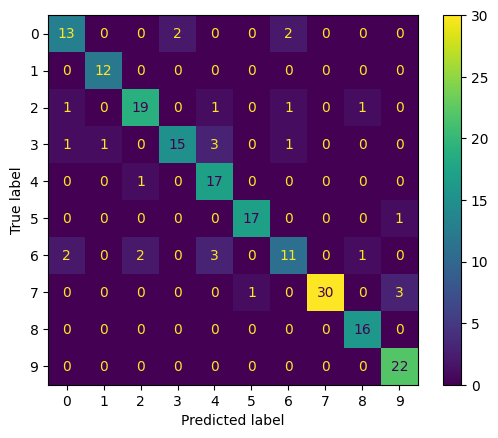

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(test_samples_labels,predictions, labels=np.unique(test_samples_labels))
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=np.unique(test_samples_labels))
import matplotlib.pyplot as plt
cm_display.plot()
plt.show()

### What to Submit
Please submit the following:

1. A Jupyter noteboon that contains your completed notebook, where the output of each cell is clearly displayed.

2. A brief write-up that answers the 5 questions posed in this lab and justifies your model. Ensure that any figures you create are accessible and easy to understand.